In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from libs.train.dataframe_splitter import split_dataframe, select_features
from sklearn.model_selection import cross_val_score
import datetime
import math
import optuna
import os


In [85]:
raw_data = pd.read_csv('data/train_set.csv')
target = pd.read_csv('data/target_set.csv')
randomState = 42

x, y = split_dataframe(raw_data, target)
X_new = select_features(x, y, 195)

In [86]:
def show_tree(model, x, figsize=None):
	if figsize != None:
		plt.figure(figsize=figsize)
	plot_tree(
		model,
		feature_names=x.columns.tolist(),
		class_names=['Not in 2022', 'In 2022'],
		filled=True,
		rounded=True,
		fontsize=10
	)
	plt.show()

def explain_tree(model, x, amount= 15):
	# Assuming 'clf' is your trained model and 'X_train' is a pandas DataFrame
	importances = model.feature_importances_
	feature_names = x.train.columns

	# Create a pandas Series for easy plotting
	feature_importance_series = pd.Series(importances, index=feature_names)

	# Plot
	plt.figure(figsize=(10, 6))
	feature_importance_series.nlargest(amount).plot(kind='barh')
	plt.title(f"Top {amount} Most Important Features")
	plt.xlabel("Importance (Mean Decrease in Impurity)")
	plt.show()

def show_confusion(y, y_pred):
	cm = confusion_matrix(y_true=y, y_pred=y_pred)
	disp = ConfusionMatrixDisplay(confusion_matrix=cm)
	disp.plot()
	plt.show()

def print_accuracy(y, y_pred):
	score = accuracy_score(
		y_true=y,
		y_pred=y_pred
	)
	print(f"accuracy: {score}")

def print_f1score(y, y_pred):
	print(f"f1Score: {get_f1score(y, y_pred)}")

def get_f1score(y, y_pred):
	return f1_score(
		y_true=y,
		y_pred=y_pred
	)

In [5]:
def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 9, 12),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 400),
        'min_samples_split': trial.suggest_int('min_samples_split', 5, 800),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 10, 100),
        'max_features': trial.suggest_int('max_features', 50, 195)
    }
    
    model = DecisionTreeClassifier(random_state=42, **params)
    
    score = cross_val_score(model, X_new.train, y.train, cv=10, scoring='f1', n_jobs=1).mean()
    return score

csv_bestandsnaam = "data/optuna_save_inbetween.csv"
def readfile():
	try:
		return pd.read_csv(csv_bestandsnaam)
	except FileNotFoundError:
		print(f"{csv_bestandsnaam} file not found.")
		return None

def savefile(df):
	df.to_csv(csv_bestandsnaam, index=True)

def getBestParams(oldResults):
    oldResults = oldResults.sort_values(by='value', ascending=False)
    bestOldTrial = oldResults.iloc[0]
    
    return {
        'max_depth': int(bestOldTrial['params_max_depth']),
        'min_samples_leaf': int(bestOldTrial['params_min_samples_leaf']),
        'min_samples_split': int(bestOldTrial['params_min_samples_split']),
        'max_leaf_nodes': int(bestOldTrial['params_max_leaf_nodes']),
        'max_features': int(bestOldTrial['params_max_features'])
    }


def shouldStop(study):
	bestCount = 0
	bestparams = None
	stopThreshold = 20

	if bestparams == study.best_params:
		bestCount += 10
		if bestCount >= stopThreshold:
			return True
		else:
			bestCount=10
			bestparams == study.best_params
	return False

def closureShouldStop(stopThreshold=500, step=10):
	bestCount = 0
	bestParams = None
	stopThreshold = stopThreshold
	step=step

	def shouldStop(study):
		nonlocal bestCount, bestParams, stopThreshold
		reset = False

		if bestParams == study.best_params:
			bestCount += step
			if bestCount >= stopThreshold:
				return True, bestCount, reset
		else:
			reset = True
			bestCount = step
			bestParams = study.best_params
			
		return False, bestCount, reset
	return shouldStop

def get_storage_name(relative_path):
	full_path = os.path.abspath(relative_path)
	database_map = os.path.dirname(full_path)
	os.makedirs(database_map, exist_ok=True)
	return f"sqlite:///{full_path}"


In [6]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
step = 50
stopThreshold = 500
shouldStop = closureShouldStop(stopThreshold=stopThreshold, step=step)

for epoch in range(0, 6000, step):
	try:
		oldResults = readfile()
		storage_name = get_storage_name("data/optuna_data1.db")

		study = optuna.create_study(
			storage=storage_name,
			study_name="optuna_data1",
			direction='maximize',
			load_if_exists=True # Hervat de *nieuwe* studie als deze crasht
		)
		
		if oldResults is not None:
			study.enqueue_trial(getBestParams(oldResults))

		study.optimize(objective, n_trials=step, n_jobs=-1)
		results_df = study.trials_dataframe()
		savefile(results_df)

		isEnding, bestCount, reset = shouldStop(study)
		print(f"Trial: {len(study.get_trials())}")
		print(f"bestCount: {bestCount}")
		if (reset):
			params = getBestParams(readfile())
			print(f"best_value: {study.best_value}")
			print(f"new beste params\n\t{params}")
		
		print()
		
		if isEnding:
			print(f"Study has completed: after {stopThreshold} runs no further runs where found")
			break
	
	except Exception as e:
		print(f"Een fout is opgetreden: {e}")

data/optuna_save_inbetween.csv file not found.
Trial: 50
bestCount: 50
new beste params
	{'max_depth': 11, 'min_samples_leaf': 101, 'min_samples_split': 63, 'max_leaf_nodes': 63, 'max_features': 169}
best_value: 0.7073283026734841

Trial: 100
bestCount: 50
new beste params
	{'max_depth': 12, 'min_samples_leaf': 19, 'min_samples_split': 90, 'max_leaf_nodes': 95, 'max_features': 161}
best_value: 0.7730884902588457

Trial: 150
bestCount: 50
new beste params
	{'max_depth': 12, 'min_samples_leaf': 13, 'min_samples_split': 19, 'max_leaf_nodes': 100, 'max_features': 195}
best_value: 0.8016673759648871

Trial: 200
bestCount: 50
new beste params
	{'max_depth': 12, 'min_samples_leaf': 15, 'min_samples_split': 30, 'max_leaf_nodes': 97, 'max_features': 191}
best_value: 0.8022344287492252

Trial: 250
bestCount: 100

Trial: 300
bestCount: 50
new beste params
	{'max_depth': 12, 'min_samples_leaf': 16, 'min_samples_split': 34, 'max_leaf_nodes': 99, 'max_features': 188}
best_value: 0.8025687394110763



features: 195
leaves: 97
accuracy: 0.9633622314361101
f1Score: 0.7949367088607595


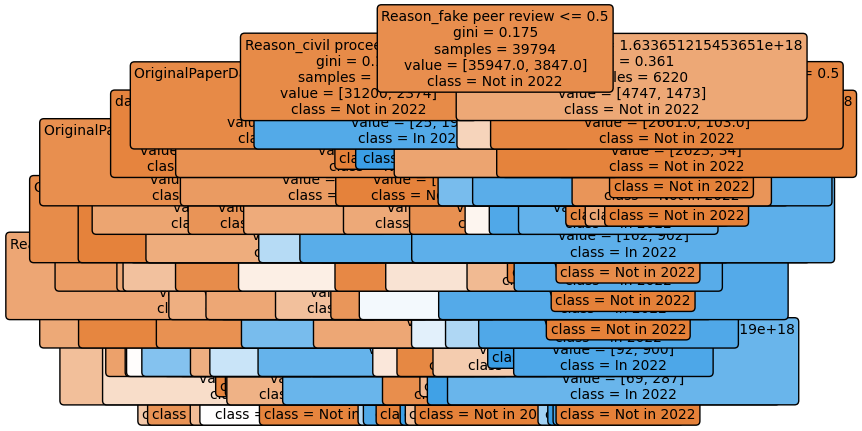

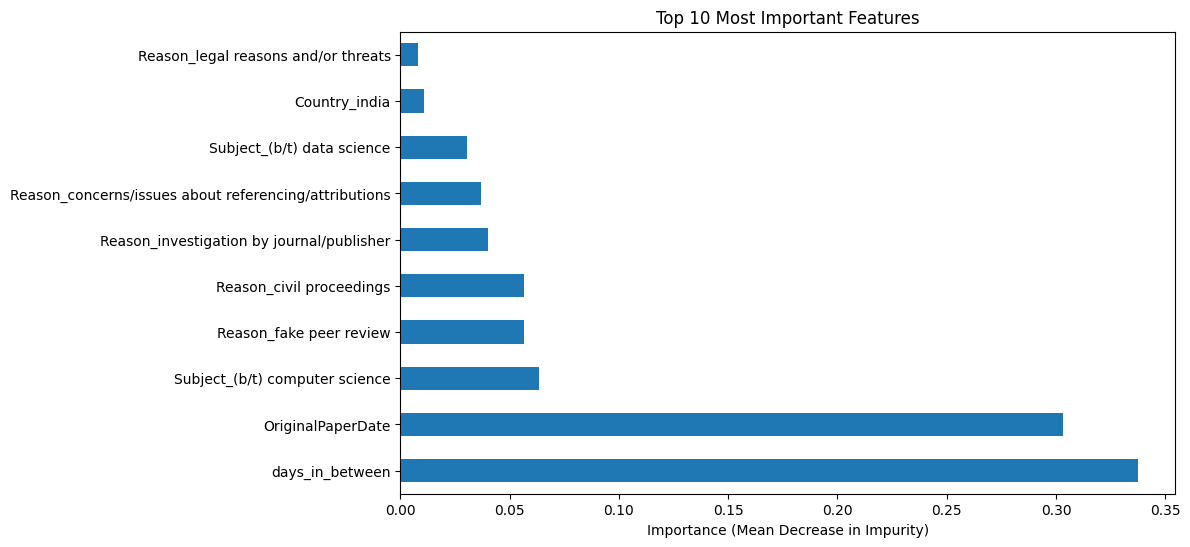

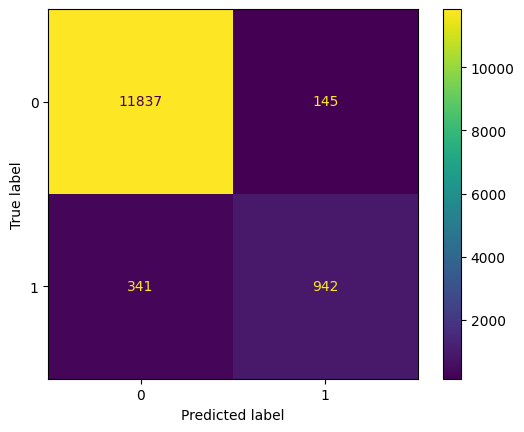

In [87]:
m = DecisionTreeClassifier(random_state=42, max_depth=12, min_samples_leaf=13, min_samples_split=36, max_leaf_nodes=97, max_features=188)
m.fit(X=X_new.train, y=y.train)
y_pred = m.predict(X=X_new.val)

print(f"features: {m.n_features_in_}")
print(f"leaves: {m.get_n_leaves()}")
print_accuracy(y.val, y_pred)
print_f1score(y.val, y_pred)
show_tree(m, X_new.val)
explain_tree(m, X_new, 10)
show_confusion(y.val, y_pred)

In [94]:
m = RandomForestClassifier(n_estimators=250, random_state=42, max_depth=12, min_samples_leaf=13, min_samples_split=36, max_leaf_nodes=97, max_features=188)
m.fit(X=X_new.train, y=y.train['in2022'])

,n_estimators,250
,criterion,'gini'
,max_depth,12
,min_samples_split,36
,min_samples_leaf,13
,min_weight_fraction_leaf,0.0
,max_features,188
,max_leaf_nodes,97
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


features: 195
leaves: 97
accuracy: 0.9688654353562005
f1Score: 0.8197293758184199


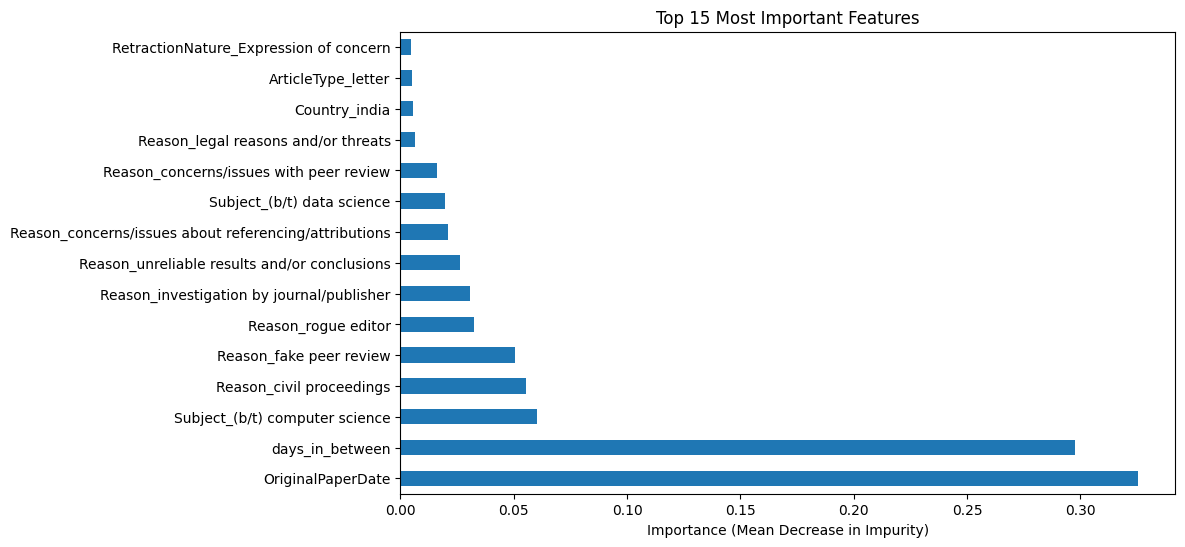

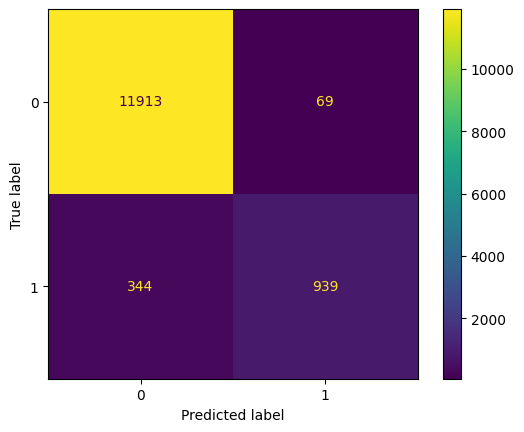

In [105]:
y_pred = m.predict(X=X_new.val)

print(f"features: {m.n_features_in_}")
print(f"leaves: {m.max_leaf_nodes}")
print_accuracy(y.val, y_pred)
print_f1score(y.val, y_pred)
explain_tree(m, X_new, 15)
show_confusion(y.val, y_pred)

In [125]:
dib = round(X_new.train['days_in_between'].median())

years = math.floor(dib/365)
days = dib%365
print(f"y:{years}-d:{days}")

opd = X_new.train['OriginalPaperDate'].median()
date_obj = pd.to_datetime(opd, unit='ns')
date = date_obj.strftime("%d-%m-%Y")
print(f"date: {date}")

y:1-d:111
date: 24-01-2018
